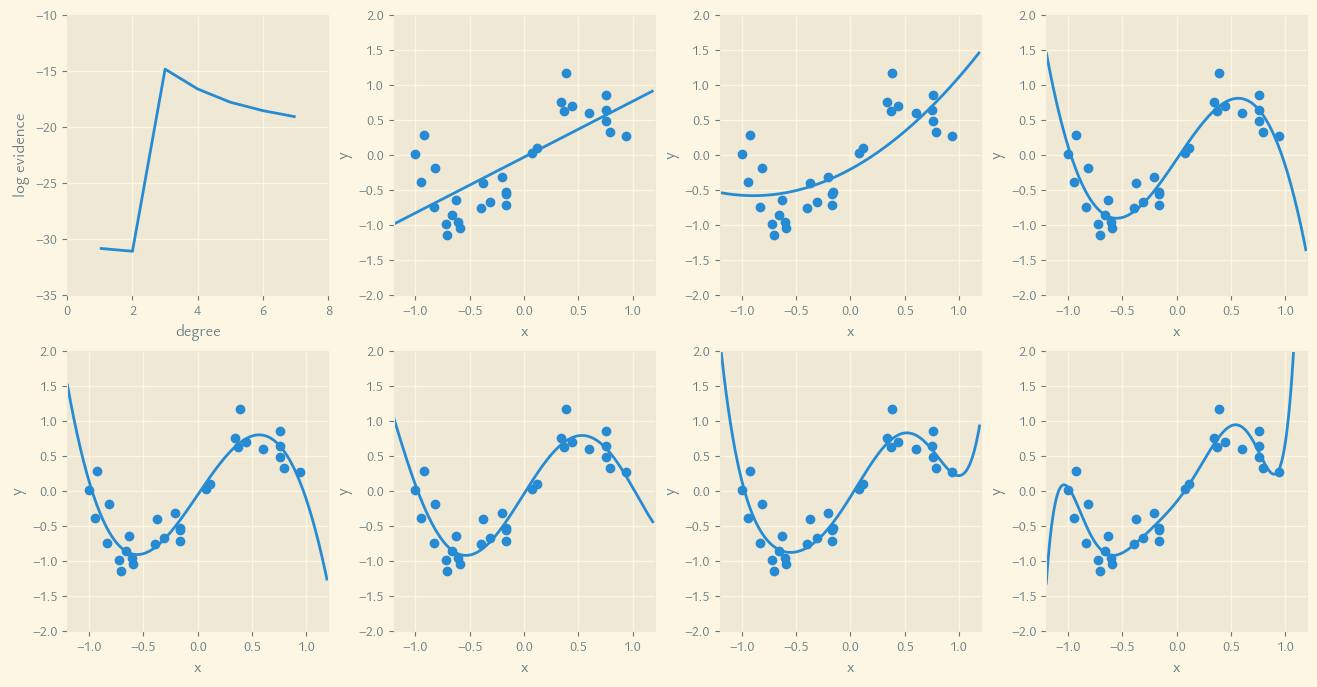

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import scipy.stats as st

plt.rcParams["font.family"] = "LXGW Bright"


def true_fun(X):
    return np.sin(np.pi * X)


np.random.seed(1)
n_samples, degree = 30, 8
a, b = 0.05, 10  # 分布超参数
x = st.uniform.rvs(loc=-1, scale=2, size=n_samples)
y = true_fun(x) + st.norm.rvs(loc=0, scale=np.sqrt(1 / b), size=n_samples)
x_plot = np.arange(-1.2, 1.2, 0.01)
evidence = []

with plt.style.context('Solarize_Light2'):
    fig, ax = plt.subplots(2, int(degree / 2), figsize=(16, 8))
    plt.subplots_adjust(wspace=0.25, hspace=0.2)
    ax = ax.ravel()

    for n in range(1, degree):

        polynomial_features = PolynomialFeatures(degree=n, include_bias=True)
        x_features = polynomial_features.fit_transform(x[:, np.newaxis])
        x_plot_features = polynomial_features.fit_transform(x_plot[:, np.newaxis])
        lr = LinearRegression()
        lr.fit(x_features, y)
        ax[n].plot(x_plot, lr.predict(x_plot_features), label='degree = %d' % (n))
        ax[n].scatter(x, y)
        ax[n].set_xlim(-1.2, 1.2)
        ax[n].set_ylim(-2, 2)
        ax[n].set_xlabel('x')
        ax[n].set_ylabel('y')

        sigma = b * x_features.T @ x_features + a * np.eye(n + 1)
        mu = b * np.linalg.inv(sigma) @ x_features.T @ y[:, np.newaxis]

        evidence.append((np.log(a) * (n + 1) + np.log(b) * n_samples - b * np.linalg.norm(y[:, np.newaxis] - x_features @ mu)**2 - a * np.linalg.norm(mu)**2 - np.log(np.linalg.det(sigma)) - np.log(2 * np.pi) * n_samples) / 2)

    ax[0].plot([i for i in range(1, degree)], evidence)
    ax[0].set_xlim(0, degree)
    ax[0].set_ylim(-35, -10)
    ax[0].set_xlabel('degree')
    ax[0].set_ylabel('log evidence')

    fig.savefig("plot-model-evidence.svg")
    plt.show()

In [ ]:
for i in range(5):
    polynomial_features = PolynomialFeatures(degree=i, include_bias=True)
    xx_plot = polynomial_features.fit_transform([[2]])
    print(xx_plot)

In [ ]:
a = np.array([1,2,3])
np.linalg.norm(a)**2